# Simulation of angular streaking with a realistic FEL

Here we simulate the effect of angular streaking in a FEL produced elsewhere.

We need to define a function E(t), which produces the x-polarized FEL electric field for a given time point. If the FEL has been simulated in a separate tool and only a grid of time points for it is available (for instance: ocelot), one can create a function that interpolates the missing points.

This will be used here to produce more realistic FEL simulations for validation.

In [1]:
using HDF5
using LaTeXStrings
using Plots
using Format

using Random, Distributions
using EllipsisNotation

using LinearInterpolations

In [2]:
include("../src/QuackSim.jl")
using .QuackSim
# if installed:
#using QuackSim

[Fri, 18 Jul 2025 11:39:47] Loading file '/gpfs/exfel/data/scratch/danilo/quack-sim/src/../data/pcs_Kr1s.txt' with data for Kr4p_multi...
[Fri, 18 Jul 2025 11:39:48] Loading file '/gpfs/exfel/data/scratch/danilo/quack-sim/src/../data/pcs_Xe.txt' with data for Xe3d...
[Fri, 18 Jul 2025 11:39:48] Loading file '/gpfs/exfel/data/scratch/danilo/quack-sim/src/../data/pcs_Kr1s.txt' with data for Kr1s...
[Fri, 18 Jul 2025 11:39:48] Loading file '/gpfs/exfel/data/scratch/danilo/quack-sim/src/../data/pcs_Ne.txt' with data for Ne1s...
[Fri, 18 Jul 2025 11:39:48] Loading file '/gpfs/exfel/data/scratch/danilo/quack-sim/src/../data/pcs_N.txt' with data for N1s...
[Fri, 18 Jul 2025 11:39:48] Loading file '/gpfs/exfel/data/scratch/danilo/quack-sim/src/../data/pcs_Xe.txt' with data for Xe5p_multi...
[Fri, 18 Jul 2025 11:39:48] Loading file '/gpfs/exfel/data/scratch/danilo/quack-sim/src/../data/pcs_Kr1s_v.txt' with data for Kr4p_multi...
[Fri, 18 Jul 2025 11:39:50] Loading file '/gpfs/exfel/data/scratch

# Open file with E-field.

In [3]:
fid = h5open("../example/fel_nochirp.h5", "r")

# for cross checks
# spectra
E_spec = read(fid["E_spec"])
t_spec = read(fid["t_spec"])
# axes
E_axis = read(fid["spec_E_axis"])
t_axis = read(fid["spec_t_axis"])

A_td = read(fid["time_domain_amplitude"])
ϕ_td = read(fid["time_domain_phase"])
t = read(fid["time_domain_axis"])
ωx = read(fid["E_photon"])/eV_per_au
E = A_td.*sin.(ωx.*t .+ ϕ_td)

E_photon = read(fid["E_photon"])
width = read(fid["width"])
envelope_width = read(fid["envelope_width"])
bw = read(fid["bw"])

close(fid)

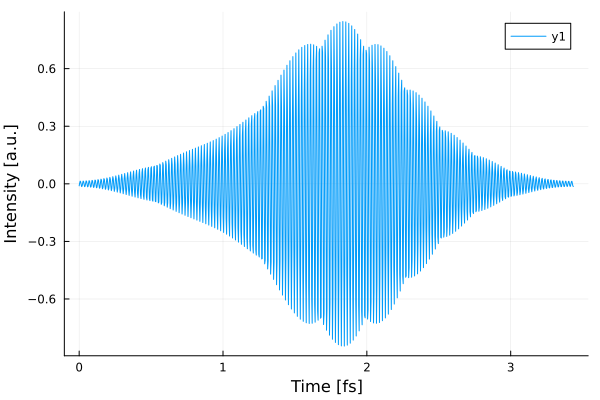

In [4]:
plot(t[1:end]*fs_per_au, E[1:end,1], xlabel="Time [fs]", ylabel="Intensity [a.u.]")

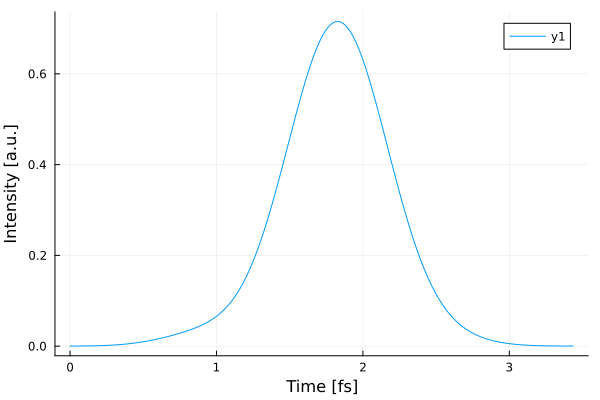

In [5]:
plot(t_axis, t_spec[:, 1], xlabel="Time [fs]", ylabel="Intensity [a.u.]")

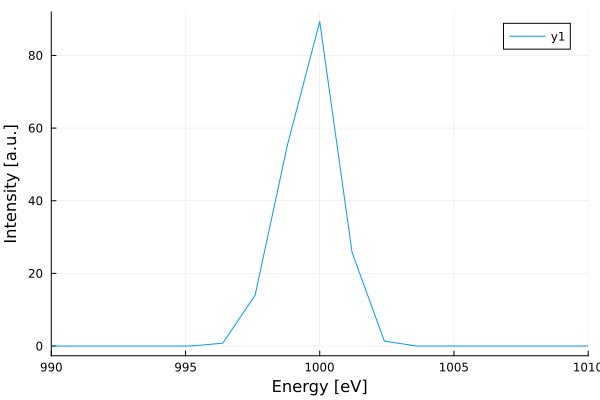

In [6]:
plot(E_axis, E_spec[:, 1], xlabel="Energy [eV]", ylabel="Intensity [a.u.]", xlim=(1e3-10, 1e3+10))

In [7]:
# PES binding energy
gas = "Ne1s"
Ip = orbitals[gas]["Ip"]/eV_per_au

# laser settings
λl = 1030.0/nm_per_au
ωl = 2π*c/λl
Tl = 2π/ωl

# amplitude of the A-field for streaking: let's bump electrons with something like +/-10 eV
# units (it is defined here scaled by c): eV/e = Volt
# in atomic units: 1 a.u. of A = 27.2 V
Up = 0.2/eV_per_au
amp_Al = sqrt.(4Up).*c
# A = -c int_-inf^t E(t') dt'

# polarization
polarization = :horizontal
beta = 2.0
tda = orbitals[gas]["tda_int"]

# create a grid for observations
W_axis = collect(LinRange(95.0/eV_per_au, 155.0/eV_per_au, 160))
θ_axis_deg = collect(LinRange(0.0, 360.0, 16))
θ_axis = deg2rad.(θ_axis_deg)

NW, Nθ = length(W_axis), length(θ_axis)

(160, 16)

The laser period must match the time axis for the FEL field approximmately (or better said, it is assumed the FEL can be extrapolated with the `Interpolator` after the end of the time axis, and if it has hit zero before, the extrpolation is simply zero).

## Propagate

Check effect of two pulses getting close together, without streaking.

In [8]:
tspan=(0.0, Tl)

(0.0, 142.09503260598152)

In [ ]:
# create the object holding all information for the integration
result = []
ellipticity = 1.0
Nsim = size(E)[2]
Random.seed!(123)
for i in 1:Nsim
    ϕ_int = Interpolate(t, ϕ_td[:,i]; extrapolate=:replicate)
    A_int = Interpolate(t, A_td[:,i]; extrapolate=:replicate)
    ϕ_fel = tx -> ϕ_int(tx)
    A_fel = tx -> A_int(tx)
    E_fel = tx -> A_fel(tx)*sin(ωx*tx + ϕ_fel(tx))
    #E_fel = Interpolate(t, E[:,i]; extrapolate=:replicate)
    p = CustomFELSFASim(W_axis, θ_axis,                   # observation Grid (eV, rad)
                        E_photon/eV_per_au,               # FEL mean energy
                        [amp_Al],                         # streaking laser vector potential amplitude (V)
                        ωl,                               # streaking laser angular frequency
                        Ip,                               # binding energy
                        ellipticity,                      # ellipticity
                        E_fel,                            # FEL electric field
                        tda,
                        false,
                        beta,
                        polarization
        )
    # returns an array of size: (NW, Nθ, NA) = (NW, Nθ, 1)
    # sum over all pairs of FEL times and energies
    @time B = calculate(p,
                        tspan,                 # time span
                        )    # slow, but careful integration
    # normalize
    B_cpu = Array(B)./sum(B);
    # take the only vector potential
    B_cpu = B_cpu[:,:,1]
    # store with an extra index, so we can concatenate over it later
    push!(result, B_cpu[[CartesianIndex()], ..])
end

[Fri, 18 Jul 2025 11:40:29] Using analytical result for ϕ(t=Tl)...
[Fri, 18 Jul 2025 11:40:35] Calculating b(t=Tl)...
[Fri, 18 Jul 2025 11:41:18] Calculating observation...
 49.797443 seconds (49.97 M allocations: 12.406 GiB, 6.05% gc time, 75.15% compilation time)
[Fri, 18 Jul 2025 11:41:20] Using analytical result for ϕ(t=Tl)...
[Fri, 18 Jul 2025 11:41:20] Calculating b(t=Tl)...
[Fri, 18 Jul 2025 11:41:32] Calculating observation...
 12.012998 seconds (4.71 M allocations: 9.551 GiB, 9.98% gc time)
[Fri, 18 Jul 2025 11:41:32] Using analytical result for ϕ(t=Tl)...
[Fri, 18 Jul 2025 11:41:32] Calculating b(t=Tl)...
[Fri, 18 Jul 2025 11:41:43] Calculating observation...
 10.286162 seconds (4.28 M allocations: 8.690 GiB, 8.27% gc time)
[Fri, 18 Jul 2025 11:41:43] Using analytical result for ϕ(t=Tl)...
[Fri, 18 Jul 2025 11:41:43] Calculating b(t=Tl)...
[Fri, 18 Jul 2025 11:41:54] Calculating observation...
 11.438356 seconds (5.14 M allocations: 10.426 GiB, 7.74% gc time)
[Fri, 18 Jul 202

In [ ]:
result = cat(result..., dims=1);

In [ ]:
heatmap(W_axis*eV_per_au,
        collect(1:Nθ),
        result[20,..]',
        yticks=(1:Nθ, θ_axis_deg),
        size=(1000, 600),
        xlabel="W [eV]",
        ylabel=L"$\theta$ [deg]")

In [ ]:
heatmap(W_axis*eV_per_au,
        collect(1:Nθ),
        result[10,..]',
        yticks=(1:Nθ, θ_axis_deg),
        size=(1000, 600),
        xlabel="W [eV]",
        ylabel=L"$\theta$ [deg]")

In [ ]:
h5open("../example/observations_nochirp.h5", "w") do fid
    # observation
    fid["obs", chunk=(1,size(result)[2:end]...), deflate=5] = result
    # photo-electron kinetic energy
    fid["W_axis"] = W_axis
    # photo-electron angle
    fid["theta_axis"] = θ_axis

    fid["amp_Al"] = amp_Al
    fid["Ip"] = Ip
    fid["Tl"] = Tl*fs_per_au
    fid["wl"] = ωl/fs_per_au
    
    # spectra
    fid["E_spec", chunk=(1, size(E_spec)[2:end]...), deflate=5] = E_spec
    fid["t_spec", chunk=(1, size(t_spec)[2:end]...), deflate=5] = t_spec
    fid["spec_E_axis", chunk=(1, size(E_axis)[2:end]...), deflate=5] = E_axis
    fid["spec_t_axis", chunk=(1, size(t_axis)[2:end]...), deflate=5] = t_axis

    fid["width"] = width
    fid["envelope_width"] = envelope_width
    fid["bw"] = bw
end